In [18]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from sktime.forecasting.naive import NaiveForecaster
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from scipy.special import inv_boxcox
from scipy.stats import boxcox
import pmdarima as pm



from sktime.performance_metrics.forecasting import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [19]:
df = pd.read_csv("Energy_Consumption.csv")
df = df.sort_values(by ="Datetime")
df = df[:3000]
df.index = range(0,len(df))

In [20]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

In [21]:
df["PJME_MW"] = pd.to_numeric(df["PJME_MW"])

In [22]:
df_difference = df.diff(18)
df_difference.dropna(inplace=True)
df_difference.describe()

,Datetime,PJME_MW
count,2982,2982.000000
mean,0 days 18:00:21.730382293,-32.116365
std,0 days 00:04:38.896487964,5789.361208
min,0 days 18:00:00,-15650.000000
25%,0 days 18:00:00,-4152.500000
50%,0 days 18:00:00,-176.500000
75%,0 days 18:00:00,4266.750000
max,0 days 19:00:00,17373.000000


In [23]:
train = df["PJME_MW"][:-int(0.2*len(df))]
test = df["PJME_MW"][-int(0.2*len(df)):]
train_df = df[:-int(0.2*len(df))]
test_df = df[-int(0.2*len(df)):]
time_stamps = int(0.2*len(df))+1

In [24]:
baseline_model = NaiveForecaster(strategy="mean")
baseline_model.fit(train)
y_pred = baseline_model.predict(fh=[i for i in range(1,time_stamps)])

In [25]:
prediction = pd.DataFrame({"PJME_MW":y_pred})
prediction["Datetime"] = test_df["Datetime"]

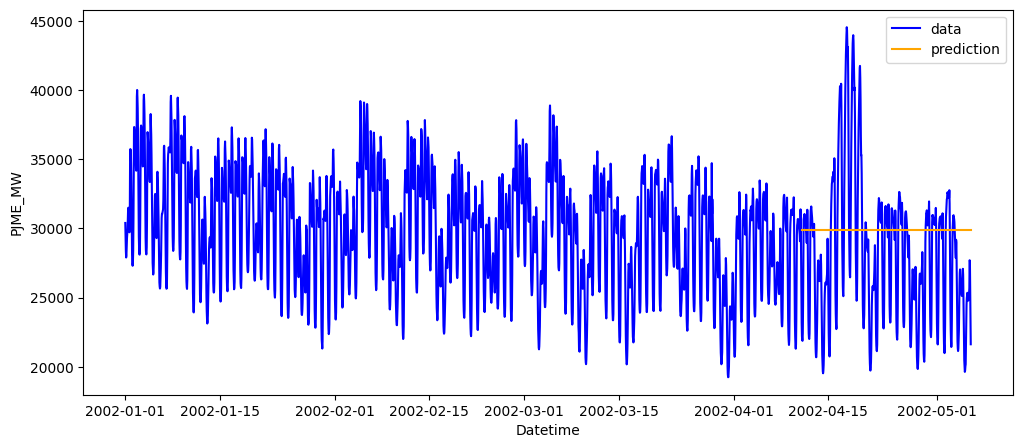

In [26]:
plt.figure(figsize=(12,5))
sns.lineplot(data=df,x="Datetime",y="PJME_MW",color="blue",label="data")
sns.lineplot(data=prediction,x="Datetime",y="PJME_MW",color="orange",label="prediction")
plt.show()

In [27]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)


MAE : 4315.0923041666665
RMSE: 5484.543975758291
MAPE: 0.1647379009652822


# Using a more sophisticated model (ARIMA) and computing the performence metrics

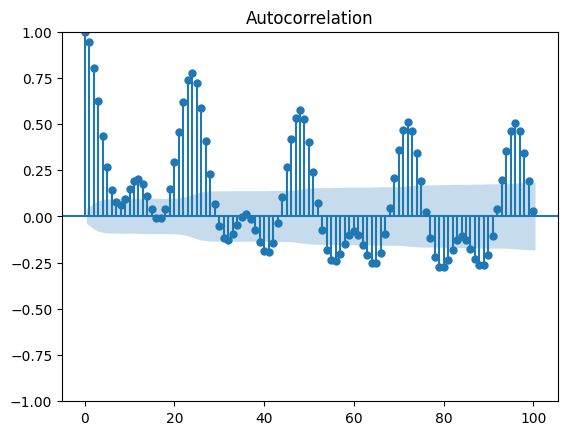

In [28]:
plot_acf(train,lags=100)
plt.show()

In [29]:
model_arima = ARIMA(train,order=(18,0,18))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [30]:
prediction = pd.DataFrame({"PJME_MW":y_pred})
prediction["Datetime"] = test_df["Datetime"]

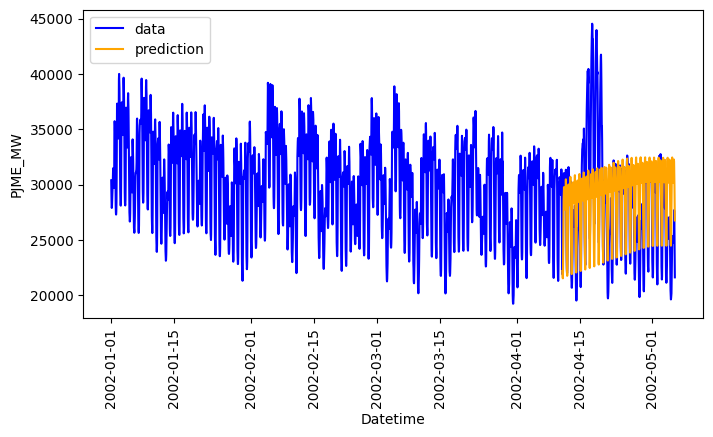

In [31]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Datetime",y="PJME_MW",color="blue",label="data")
sns.lineplot(data=prediction,x="Datetime",y="PJME_MW",color="orange",label="prediction")
plt.xticks(rotation=90)
plt.show()

In [32]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 3154.3504239596373
RMSE: 4278.714520329352
MAPE: 0.11165728127193447


# Testing a different refinement method each time and looking at the performence

* The Box Cox

In [33]:
train_BoxCox, lam = boxcox(train)
model_arima = ARIMA(train_BoxCox,order=(18,0,18))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))
y_pred = inv_boxcox(y_pred,lam)

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [34]:
prediction = pd.DataFrame({"PJME_MW":y_pred})
prediction.index = range(2400,2400+len(prediction))
prediction["Datetime"] = test_df["Datetime"]

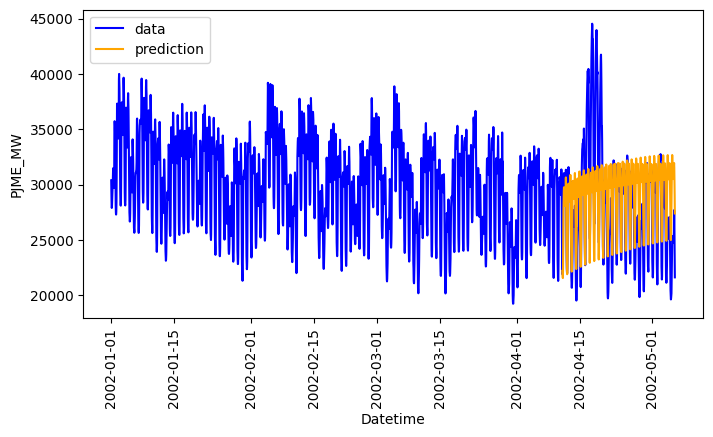

In [35]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Datetime",y="PJME_MW",color="blue",label="data")
sns.lineplot(data=prediction,x="Datetime",y="PJME_MW",color="orange",label="prediction")
plt.xticks(rotation=90)
plt.show()

In [36]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 3223.98870342203
RMSE: 4296.189524681523
MAPE: 0.11533909399683281


* IQR impuration with the median

In [37]:
median = np.median(train)
train_IQR = train.copy()
for i in range(len(train_IQR)):
    if train_IQR[i]>median*1.5:
        train_IQR[i] = median
        

In [38]:
model_arima = ARIMA(train_IQR,order=(18,0,18))
model_arima = model_arima.fit()
y_pred = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [39]:
prediction = pd.DataFrame({"PJME_MW":y_pred})
prediction["Datetime"] = test_df["Datetime"]

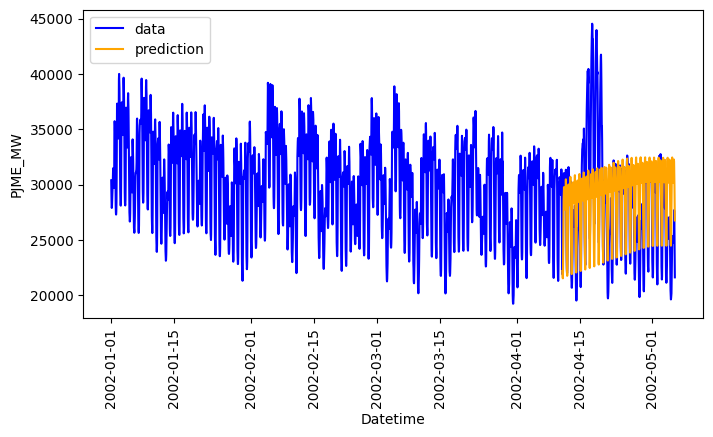

In [40]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Datetime",y="PJME_MW",color="blue",label="data")
sns.lineplot(data=prediction,x="Datetime",y="PJME_MW",color="orange",label="prediction")
plt.xticks(rotation=90)
plt.show()

In [41]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 3154.3504239596373
RMSE: 4278.714520329352
MAPE: 0.11165728127193447


* Fourier Trend

In [42]:
df_fourier = df.copy()

In [43]:
t = np.arange(len(df_fourier))
for order in range(1,10):
    df_fourier[f"fourier_sin_order_{order}"] = np.sin(2* np.pi * order * t/18)
    df_fourier[f"fourier_cos_order_{order}"] = np.cos(2* np.pi * order * t/18)
    
fourier_features = [i for i in list(df_fourier) if i.startswith("fourier")]
train_df_fourier = df_fourier[:-int(0.2*len(df))]
test_df_fourier = df_fourier[-int(0.2*len(df)):]

In [44]:
model = pm.auto_arima(
    train_df_fourier["PJME_MW"],
    X = train_df_fourier[fourier_features],
    seasonal = False,
    stepwise = True,
    suppress_warnings = True,
    max_order = None,
    information_criterion = "aicc",
    error_action = "ignore"
)
y_pred = model.predict(n_periods = len(test_df_fourier), X=test_df_fourier[fourier_features])

In [45]:
prediction = pd.DataFrame({"PJME_MW":y_pred})
prediction["Datetime"] = test_df["Datetime"]

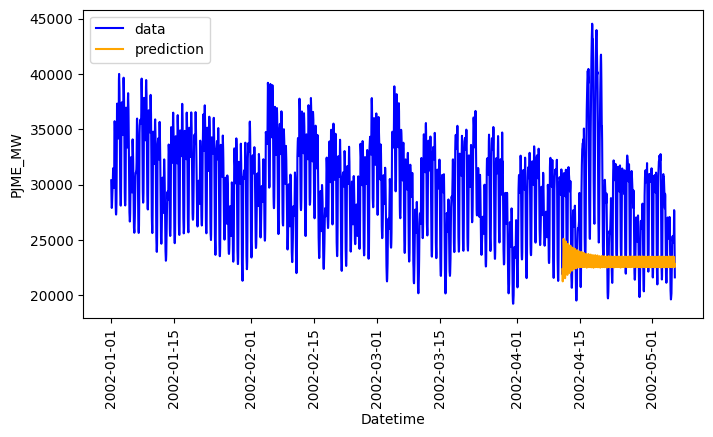

In [46]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df_fourier,x="Datetime",y="PJME_MW",color="blue",label="data")
sns.lineplot(data=prediction,x="Datetime",y="PJME_MW",color="orange",label="prediction")
plt.xticks(rotation=90)
plt.show()

In [47]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 5708.319941326156
RMSE: 7320.8377988390785
MAPE: 0.18274979671047856


* Seasonal Differencing

In [48]:
df_diff = df.copy()
df_diff["PJME_MW"] = df["PJME_MW"].diff(18)
df_diff["Datetime"] = df["Datetime"]
train_diff = df["PJME_MW"][:-int(0.2*len(df))]
test_diff = df["PJME_MW"][-int(0.2*len(df)):]

train_diff.dropna(inplace=True)

In [49]:
train_diff = df_diff["PJME_MW"]

In [50]:
model_arima = ARIMA(train_diff,order=(18,0,18))
model_arima = model_arima.fit()
y_pred_diff = model_arima.forecast(len(test))

/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/adam/miniconda3/envs/homewk/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [51]:
y_pred_diff = list(y_pred_diff)

In [52]:
y_pred = []
for i in range(len(test)):
    if i<18:
        value = df.iloc[int(-len(df)*0.2)-18+i].loc["PJME_MW"]
        y_pred.append(y_pred_diff[i]+value)
    else:
        y_pred.append(y_pred_diff[i]+y_pred[-18])
        

In [53]:
prediction = pd.DataFrame({"PJME_MW":y_pred})
prediction.index = range(2400,2400+len(test))
prediction["Datetime"] = test_df["Datetime"]


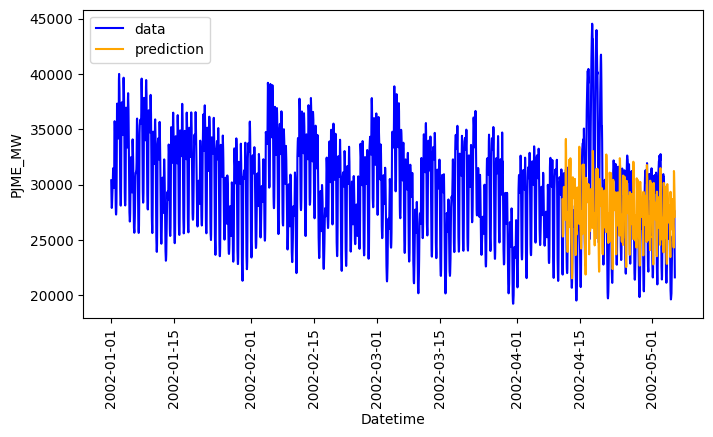

In [54]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df,x="Datetime",y="PJME_MW",color="blue",label="data")
sns.lineplot(data=prediction,x="Datetime",y="PJME_MW",color="orange",label="prediction")
plt.xticks(rotation=90)
plt.show()

In [55]:
mae = mean_absolute_error(test, y_pred)
rmse = mean_squared_error(test, y_pred, square_root=True)
mape = mean_absolute_percentage_error(test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 3723.812299596016
RMSE: 4797.455909584134
MAPE: 0.13009233784037177
